The goal of this notebook is to analyse and aggregate the bureau table, combine it with the bureau_balance table, and use the derived information to enhance predictions in the application.

# Setup

In [ ]:
from helpers import preprocessing
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import importlib
from helpers.utils import unsupervised_helper

In [2]:
bureau = preprocessing.load_pkl_to_preprocessor('bureau')
display(bureau.convert_all('category').info(show_counts=True))
print(bureau.column_structure)
bureau_df = bureau.data

Loading tables: ['bureau.csv']
loaded bureau with shape (1716428, 17)
dict_keys(['credit_status', 'bureau_overdue', 'time_variables', 'bureau', 'bureau_balance', 'pos_cash_balance', 'balance_limits', 'drawings_payments', 'contract_installments', 'credit_card_balance', 'previous_application', 'installments_payments'])
No missing columns.
Unexpected columns: ['SK_ID_BUREAU', 'SK_ID_CURR']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype   
---  ------                  --------------    -----   
 0   SK_ID_CURR              1716428 non-null  int64   
 1   SK_ID_BUREAU            1716428 non-null  int64   
 2   CREDIT_ACTIVE           1716428 non-null  category
 3   CREDIT_CURRENCY         1716428 non-null  category
 4   DAYS_CREDIT             1716428 non-null  int64   
 5   CREDIT_DAY_OVERDUE      1716428 non-null  int64   
 6   DAYS_CREDIT_ENDDATE     1610875 non-null  fl

None

['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']


# EDA

### Bureau Description:
bureau.csv

* All client's previous credits provided by other financial institutions that were reported to Credit Bureau (for clients who have a loan in our sample).
* For every loan in our sample, there are as many rows as number of credits the client had in Credit Bureau before the application date.



#### unique applicants

The application train and test tables are 307511 and 48744 values, respectively. For a total of 356255

In [3]:
print("Unique clients in bureau:", bureau_df["SK_ID_CURR"].unique().shape[0])
print(
    "Difference from application train and test:",
    bureau_df["SK_ID_CURR"].unique().shape[0] - 356255,
)

Unique clients in bureau: 305811
Difference from application train and test: -50444


A significant portion of applicants have no known history of previous loans within the bureau. NaN robust techniques or imputation will be required to make the information usable for further analysis.

Text(0, 0.5, 'Number of clients')

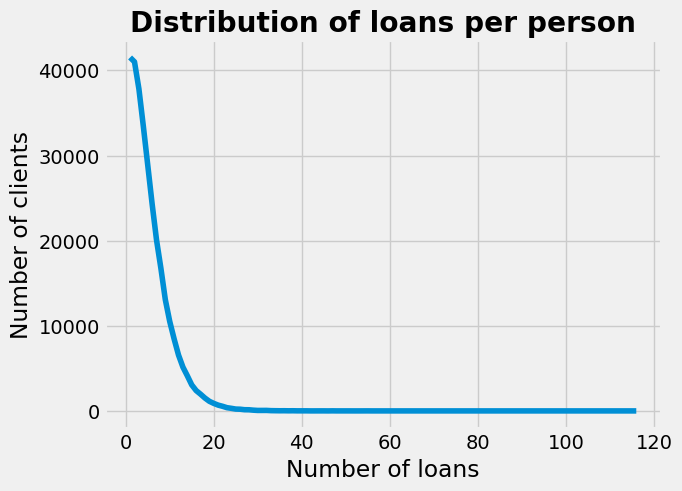

In [4]:
loans_per_person = bureau_df.groupby("SK_ID_CURR").size().value_counts().reset_index()
loans_per_person.columns = ['loans', 'instances']
sns.lineplot(data=loans_per_person, x='loans', y= 'instances')
plt.title("Distribution of loans per person")
plt.xlabel("Number of loans")
plt.ylabel("Number of clients")

* Almost all individuals have had less than 20 loans.
* Loan distribution can be modelled as poisson distribution.
* More nuanced aggregation than mean or median is required.

### Variable correlation

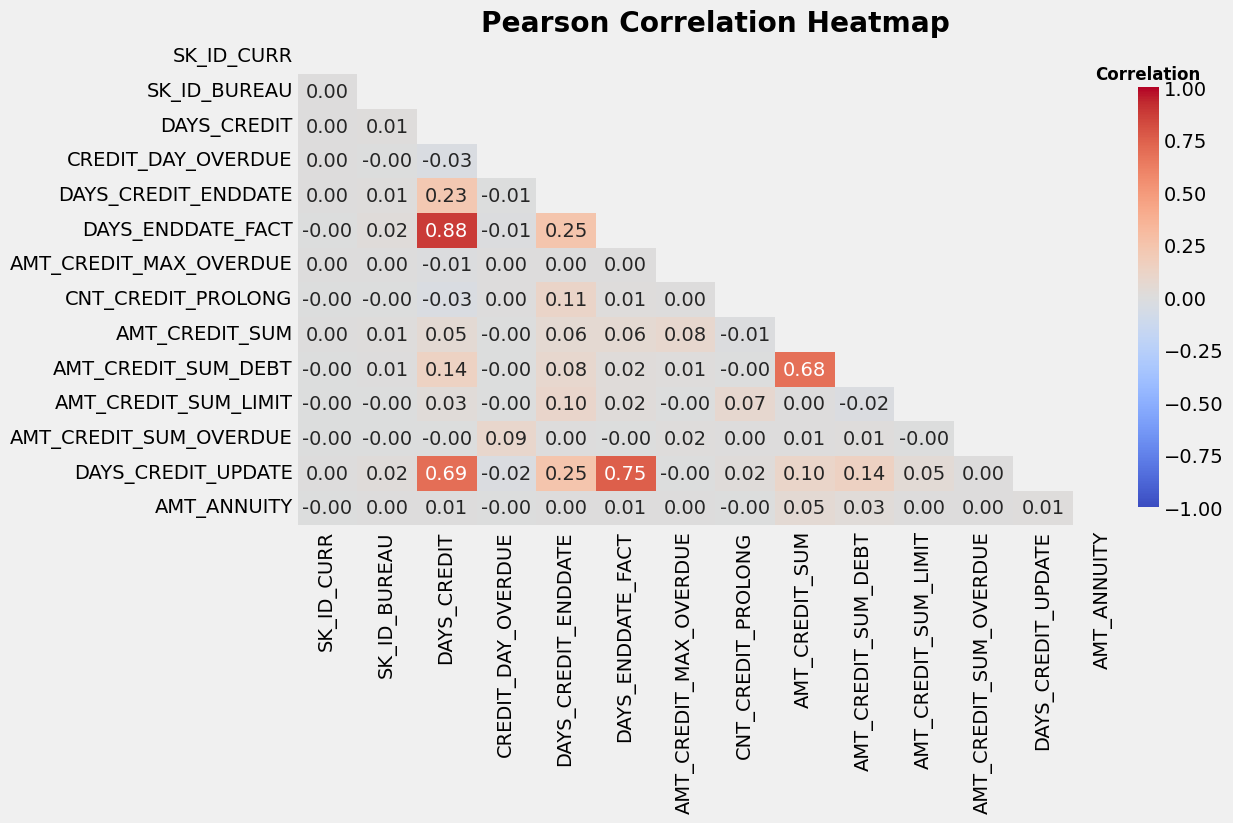

In [5]:
from helpers.utils import plotting_helper
importlib.reload(plotting_helper)

plotting_helper.plot_corr_triangle(bureau_df, figsize=(12, 6), square=False, annot=True);

* Majority of variables are semi orthogonal:

The followign variables are involved in strong positive associations:
* `DAYS_CREDIT` - How many days before current application did client apply for Credit Bureau credit.
* `DAYS_CREDIT_ENDDATE` - Remaining duration of CB credit (in days) at the time of application in Home Credit.
* `DAYS_ENDDATE_FACT` - Days since CB credit ended at the time of application in Home Credit (only for closed credit).
* `DAYS_CREDIT_UPDATE` - How many days before loan application did last information about the Credit Bureau credit come.
* `AMT_CREDIT_SUM` - Current credit amount for the Credit Bureau credit.
* `AMT_CREDIT_SUM_DEPT` - Current debt on Credit Bureau credit.


# Unsupervised learning

## PCA

Plotting 3D PCA with discarded NANs


* 4 or 5 groups can be separated from 3 axis PCA, which implies that unsupervised learning approach might yield further insight

## grouping (HDBSCAN)

c:\GITHUB\Turing submissions\psauci-DS.v2.5.3.4.1\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\GITHUB\Turing submissions\psauci-DS.v2.5.3.4.1\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



[-1  0  1  2  3  4  5  6  7  8  9 10]


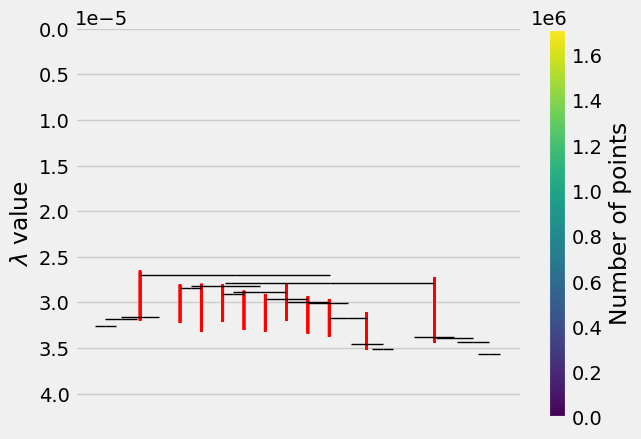

In [ ]:
import hdbscan
import numpy as np

X = bureau_df.select_dtypes(include=[np.number]).dropna(axis=1, how='all')

clusterer = hdbscan.HDBSCAN(min_cluster_size=100)
labels= clusterer.fit_predict(X)
clusterer.condensed_tree_.plot(select_clusters=True)

print(np.unique(labels))



In [23]:
X['group'] = labels.astype(str)
unsupervised_helper.plotly_3d_pca(X, hue_col='group')

Plotting 3D PCA with discarded NANs


## Supplementations of applications by state.
We include the last 5 stages of information to supplement the application table. The heuristic is that most recent data will be most relevant for individuals status.

In [7]:
balance_5 = balance.data[balance.data["MONTHS_BALANCE"] >= -5].copy()
balance_5 = balance_5.pivot_table(
    index="SK_ID_BUREAU", columns="MONTHS_BALANCE", values="STATUS", aggfunc="first"
)
balance_5.reset_index(inplace=True)
balance_5 = balance_5.merge(
    balance.data.groupby("SK_ID_BUREAU")["MONTHS_BALANCE"].min(),
    on="SK_ID_BUREAU",
    how="left",
)
balance_5.head(5)

NameError: name 'balance' is not defined

In [ ]:
import importlib

from sklearn.tests.test_min_dependencies_readme import extra
importlib.reload(preprocessing)
app = preprocessing.load_pkl_to_preprocessor('application_test')
app.convert_all('category')
app = app.get_expected_df(extra=['SK_ID_BUREAU'])
print(app.columns)
app = app.merge(balance_5, on='SK_ID_BUREAU', how='left')

NameError: name 'importlib' is not defined